# Linear Regression

## Load datasets

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

# Load datasets
df = pd.read_csv("../datasets/Salary Data.csv")

In [7]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,373.0,37.431635,7.069073,23.0,31.0,36.0,44.0,53.0
Years of Experience,373.0,10.030831,6.557007,0.0,4.0,9.0,15.0,25.0
Salary,373.0,100577.345845,48240.013482,350.0,55000.0,95000.0,140000.0,250000.0


In [9]:
df.describe(include="object").T

,count,unique,top,freq
Gender,373,2,Male,194
Education Level,373,3,Bachelor's,224
Job Title,373,174,Director of Marketing,12


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


## Select needed data

In [11]:
df.drop(
    columns=[col for col in df.columns if col not in ["Years of Experience", "Salary"]],
    inplace=True
)

In [12]:
df.head()

,Years of Experience,Salary
0,5.0,90000.0
1,3.0,65000.0
2,15.0,150000.0
3,7.0,60000.0
4,20.0,200000.0


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Years of Experience,373.0,10.030831,6.557007,0.0,4.0,9.0,15.0,25.0
Salary,373.0,100577.345845,48240.013482,350.0,55000.0,95000.0,140000.0,250000.0


## Check and Cleaning data

In [14]:
print("Null data: ")
df.isnull().sum()

Null data: 


Years of Experience    2
Salary                 2
dtype: int64

In [15]:
df.dropna(inplace=True)
df.isnull().sum()

Years of Experience    0
Salary                 0
dtype: int64

## Check outlier and Clean

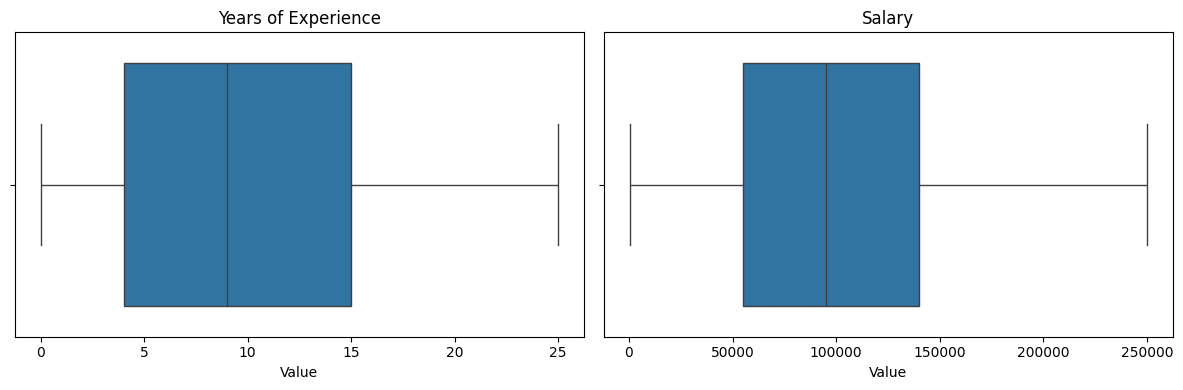

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df["Years of Experience"], ax=axes[0])
axes[0].set_title("Years of Experience")
axes[0].set_xlabel("Value")

sns.boxplot(x=df["Salary"], ax=axes[1])
axes[1].set_title("Salary")
axes[1].set_xlabel("Value")

plt.tight_layout()
plt.show()

OK there is no outlier data!

## Splitting data

In [17]:
def train_test_split(X, y, test_size=0.2, random_state=None):
    if random_state:
        np.random.seed(random_state)

    n_samples = len(X)

    shuffle_indices = np.random.permutation(np.arange(n_samples))

    test_size = round(test_size * n_samples)
    train_size = n_samples - test_size

    train_indices = shuffle_indices[:train_size]
    test_indices = shuffle_indices[train_size:]

    X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
    y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]

    return [X_train, X_test, y_train, y_test]

X = df["Years of Experience"]
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2)

In [18]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print()
print("Total data      :", len(X_train) + len(X_test))
print("Train data (%)  :", round(len(X_train) / (len(X_train) + len(X_test)) * 100, 2))
print("Test data (%)   :", round(len(X_test) / (len(X_train) + len(X_test)) * 100, 2))

X_train shape: (298,)
X_test shape : (75,)
y_train shape: (298,)
y_test shape : (75,)

Total data      : 373
Train data (%)  : 79.89
Test data (%)   : 20.11


## Make Model

In [19]:
class SimpleLinearRegression():
    def __init__(self):
        self._beta1 = 0
        self._beta0 = 0
        self.errors = list()

    def fit(self, X_train, y_train):
        x_avg = np.mean(X_train)
        y_avg = np.mean(y_train)

        # calc beta1
        nemurator = np.sum((X_train - x_avg) * (y_train - y_avg))
        denominator = np.sum(np.power((X_train - x_avg), 2))
        self._beta1 = nemurator / denominator

        # calc beta0
        self._beta0 = y_avg - (self._beta1*x_avg)

        self.errors.append(y_train - (self._beta0 + self._beta1 * X_train))

    def predict(self, X_test):
        return [(self._beta0 + self._beta1 * x) for x in X_test]

## Implements model

In [20]:
model = SimpleLinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [21]:
model._beta0, model._beta1

(31539.97197849989, 6835.0307082667005)

$$
f(x) = 31539.97197849989 + 6835.0307082667005 * x
$$

In [22]:
model.errors

[200     4924.383148
 99    -58240.586144
 330    -2045.064103
 179     1759.413856
 120   -47735.494019
            ...     
 64     -3375.002687
 42      7954.935897
 81    -40395.371186
 191     8594.444564
 273    11759.413856
 Length: 298, dtype: float64]

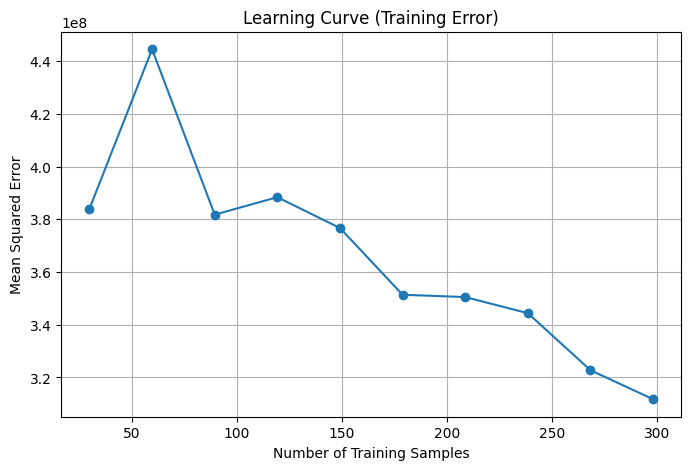

In [23]:
train_sizes = np.linspace(0.1, 1.0, 10)
train_mse = []

for size in train_sizes:
    n_train = int(len(X_train) * size)

    X_sub = X_train[:n_train]
    y_sub = y_train[:n_train]

    model = SimpleLinearRegression()
    model.fit(X_sub, y_sub)

    residuals = model.errors[0]
    mse = np.mean(residuals**2)

    train_mse.append(mse)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes * len(X_train), train_mse, marker="o")
plt.xlabel("Number of Training Samples")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curve (Training Error)")
plt.grid(True)
plt.show()

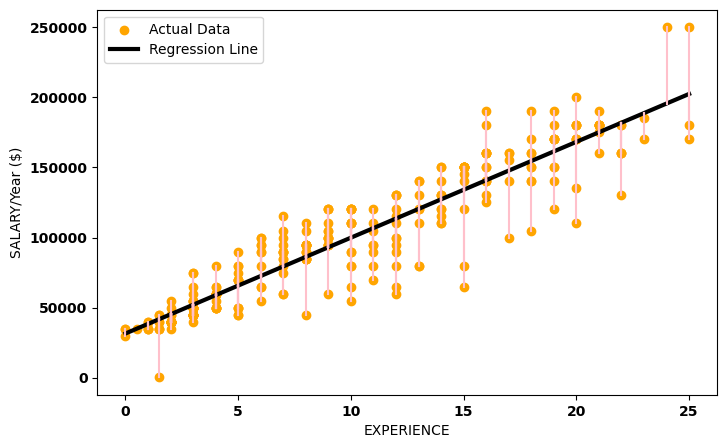

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(X_train, y_train, color='orange', label="Actual Data")

x_range = np.linspace(min(X_train), max(X_train), 100)
y_pred_range = model._beta0 + model._beta1 * x_range
plt.plot(x_range, y_pred_range, color='black', linewidth=3, label="Regression Line")

y_pred_train = model.predict(X_train)
for i in range(len(X_train)):
    plt.plot([X_train.iloc[i], X_train.iloc[i]],
             [y_train.iloc[i], y_pred_train[i]],
             color='pink', linewidth=1.5)

plt.xlabel("EXPERIENCE")
plt.ylabel("SALARY/Year ($)")
plt.xticks(fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')
plt.legend()
plt.show()

## Evaluation

In [25]:
class RegressionEvaluation():
  def mean_squere_error(self, y_true, y_pred):
    return np.mean(np.power((y_true - y_pred), 2))

  def root_mean_squere_error(self, y_true, y_pred):
    return np.sqrt(self.mean_squere_error(y_true, y_pred))

  def mean_absolute_error(self, y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

  def r2_squared(self, y_true, y_pred):
    rss = np.sum(np.power((y_true - y_pred), 2))
    tss = np.sum(np.power((y_true - np.mean(y_true)), 2))
    return 1 - (rss / tss) if tss != 0 else 0

  def make_report(self, y_true, y_pred):
    report = {
        "MSE": self.mean_squere_error(y_true, y_pred),
        "MAE": self.mean_absolute_error(y_true, y_pred),
        "RMSE": self.root_mean_squere_error(y_true, y_pred),
        "R2 Squared": self.r2_squared(y_true, y_pred),
    }
    return pd.DataFrame([report])

## Implements evaluation methods

In [26]:
pd.options.display.float_format = "{:.5f}".format

eval = RegressionEvaluation()
eval.make_report(y_test, y_pred)

,MSE,MAE,RMSE,R2 Squared
0,314700008.38750,12221.24484,17739.78603,0.85820


In [27]:
pd.concat([pd.DataFrame(y_test).reset_index(drop=True),
           pd.DataFrame(y_pred, columns=["ŷ"]).reset_index(drop=True)], axis=1)

,Salary,ŷ
0,95000.00000,99890.27906
1,120000.00000,106725.30977
2,170000.00000,161405.55544
3,60000.00000,58880.09481
4,100000.00000,127230.40189
...,...,...
70,40000.00000,45210.03340
71,90000.00000,79385.18694
72,110000.00000,154570.52473
73,50000.00000,52045.06410


Mencoba menebak secara manual baik dari data training atau manual

In [28]:
def predict_value(x):
    result = model.predict([x])
    salary = result[0]
    return f"${salary:,.2f}"


interface = gr.Interface(
    fn=predict_value,
    inputs=gr.Number(label="Lama pengalaman kerja (tahun)"),
    outputs=gr.Textbox(label="Perkiraan gaji"),
    title="Estimasi Gaji Berdasarkan Pengalaman",
    description="Masukkan lama pengalaman kerja untuk mendapatkan estimasi gaji (USD)",
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
